In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

np.random.seed(42)

In [2]:
# To comapre fairly with the Keras model, I am gonna use the same preprocessed data
df = pd.read_csv('cleaned_data.csv')
df.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,WeekStatus,Day_of_week_Monday,Day_of_week_Thursday,Day_of_week_Tuesday,Day_of_week_Wednesday,Load_Type_Maximum_Load,Load_Type_Medium_Load,NSM_sin,NSM_cos,month_sin,month_cos
0,3.17,2.95,0.0,0,1,0,0,0,0,0,0.065403,0.997859,0.5,0.866025
1,4.00,4.46,0.0,0,1,0,0,0,0,0,0.130526,0.991445,0.5,0.866025
2,3.24,3.28,0.0,0,1,0,0,0,0,0,0.195090,0.980785,0.5,0.866025
3,3.31,3.56,0.0,0,1,0,0,0,0,0,0.258819,0.965926,0.5,0.866025
4,3.82,4.50,0.0,0,1,0,0,0,0,0,0.321439,0.946930,0.5,0.866025


In [3]:
# Same temporal split as the Keras notebook

X = df.drop('Usage_kWh',axis=1)
y = df['Usage_kWh']

splitter  = len(X)
train_end = int(splitter*0.70)
val_end = train_end +int(splitter * 0.15)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

print('Train:', X_train.shape, ' Val:', X_val.shape, ' Test:', X_test.shape)
print(f'Train target mean: {y_train.mean():.2f}, Val: {y_val.mean():.2f}, Test: {y_test.mean():.2f}')

Train: (24528, 13)  Val: (5256, 13)  Test: (5256, 13)
Train target mean: 28.70, Val: 24.07, Test: 24.59


In [4]:
# Dropping the same low importance features as the Keras notebook
# The Keras notebook used permutation importance
# Day of week columns < 0.01 importance. Same drop here for fair comparison
drop_columns = [column for column in X_train.columns if 'Day_of_week' in column]

X_train = X_train.drop(columns=drop_columns)
X_val = X_val.drop(columns=drop_columns)
X_test = X_test.drop(columns=drop_columns)

print("Shape of training data:", X_train.shape, y_train.shape)
print('Shape of validation data:', X_val.shape, y_val.shape)
print("Shape of test data:", X_test.shape, y_test.shape)

Shape of training data: (24528, 9) (24528,)
Shape of validation data: (5256, 9) (5256,)
Shape of test data: (5256, 9) (5256,)


In [5]:
# XGBoost with early stopping on validation data

model = XGBRegressor(objective='reg:squarederror',n_estimators=1000, learning_rate=0.1,
                     max_depth=6,subsample=0.8, colsample_bytree=0.8, early_stopping_rounds=50,
                     random_state=42,n_jobs=-1)

model.fit(X_train, y_train,eval_set=[(X_train, y_train), (X_val, y_val)], verbose=50)

print(f"\n best iteration: {model.best_iteration}")
print(f"best val score rmse: {model.best_score:.4f}")

[0]	validation_0-rmse:31.64411	validation_1-rmse:28.00532
[50]	validation_0-rmse:6.92467	validation_1-rmse:10.99743
[67]	validation_0-rmse:6.72979	validation_1-rmse:11.22218

 best iteration: 17
best val score rmse: 9.2973


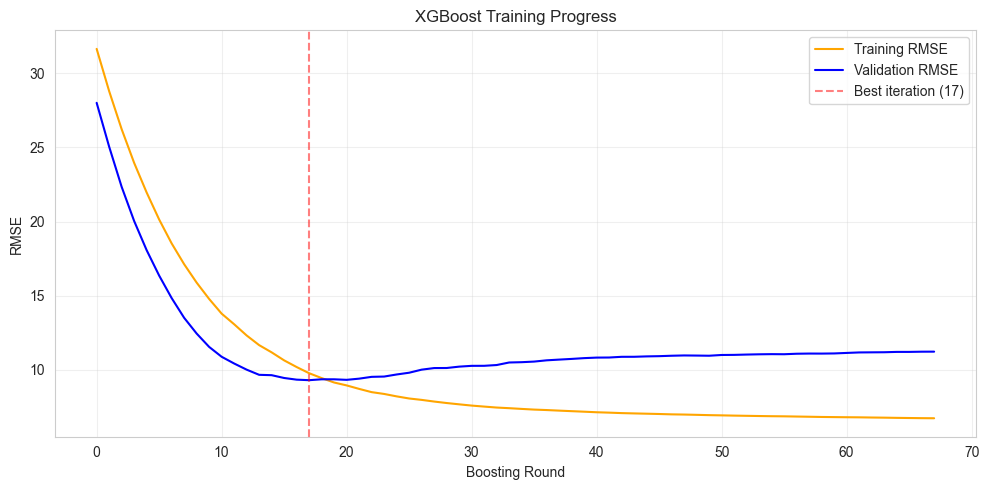

In [ ]:
# Training curves: XGBoost logs eval metrics per round
results = model.evals_result()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results['validation_0']['rmse'], label='Training RMSE', color='orange')
ax.plot(results['validation_1']['rmse'], label='Validation RMSE', color='blue')
ax.axvline(x=model.best_iteration, color='red', linestyle='--', alpha=0.5, label=f'Best iteration ({model.best_iteration})')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('RMSE')
ax.set_title("XGBoost Training Progress")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# For better visualization, I used QWEN.

In [ ]:
# Evaluating on the same test data as the Keras notebook
y_predicted = model.predict(X_test)

mse = mean_squared_error(y_test, y_predicted)
rmse = np.sqrt(mse)
mae= mean_absolute_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)

print(f'Test MSE: {mse:.3f}')
print(f"Test RMSE: {rmse:.3f}")
print(f'Test MAE: {mae:.3f} kWh')
print(f"Test R2: {r2:.3f}")

Test MSE: 69.234
Test RMSE: 8.321
Test MAE: 6.650 kWh
Test R2: 0.929


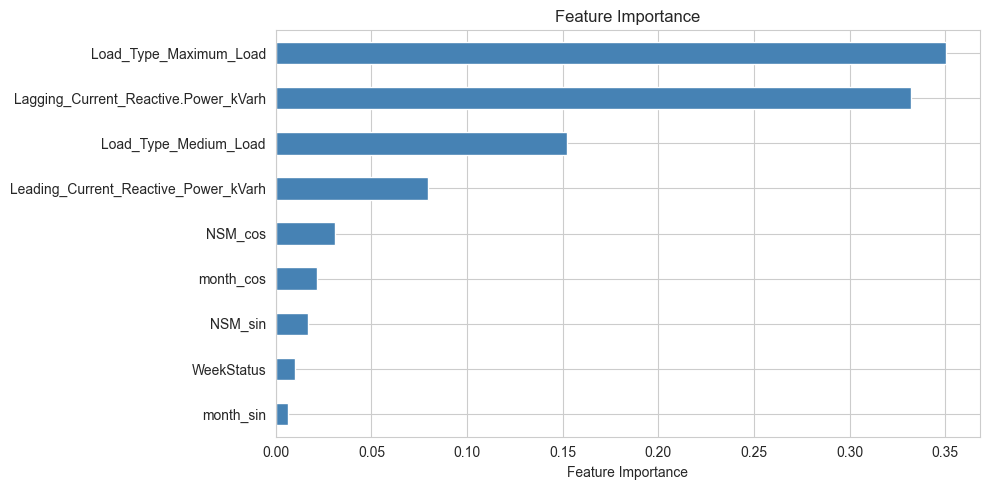

In [ ]:
# In here I am gonna check which features does XGBoost actually rely on?
# Feature importance
importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
importance.plot(kind='barh', color='steelblue')
plt.xlabel('Feature Importance')
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

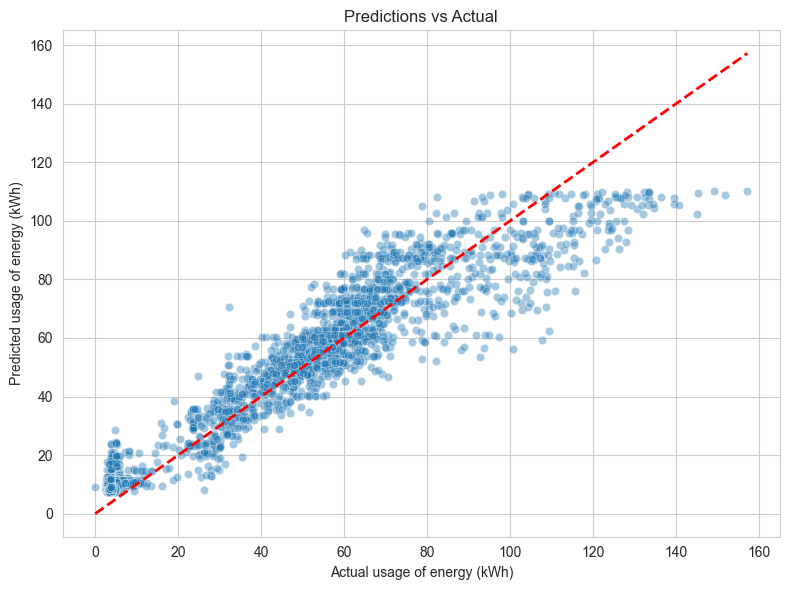

In [ ]:
# Predicted vs actual values. 

sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_predicted, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual usage of energy (kWh)')
plt.ylabel("Predicted usage of energy (kWh)")
plt.title('Predictions vs Actual')
plt.tight_layout()
plt.show()

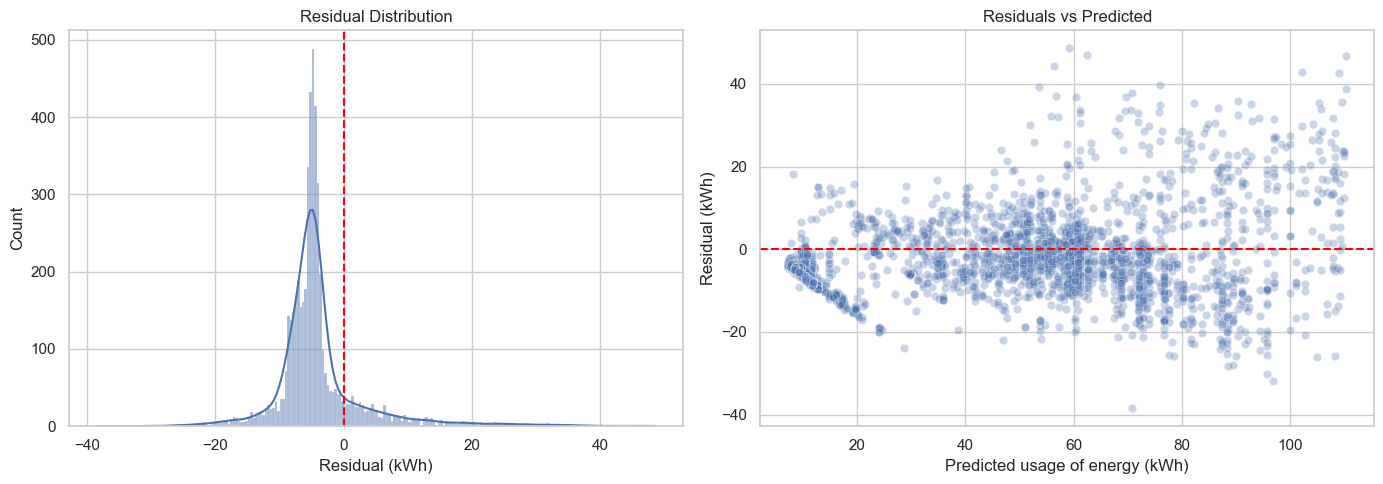

Residual mean: -3.73 kWh
Residual std: 7.44 kWh


In [52]:
# Residual analysis
sns.set_theme(style='whitegrid')

residuals = y_test.to_numpy() - y_predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set(title="Residual Distribution", xlabel='Residual (kWh)')

sns.scatterplot(x=y_predicted, y=residuals, alpha=0.3, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set(title="Residuals vs Predicted", xlabel='Predicted usage of energy (kWh)', ylabel='Residual (kWh)')

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.2f} kWh")
print(f'Residual std: {residuals.std():.2f} kWh')

<center><h2>Hyperparameter Tuning</h2></center>

In [ ]:
X_trainval = pd.concat([X_train, X_val])
y_trainval= pd.concat([y_train,y_val])

param_grid = {'max_depth': [4, 6, 8],'learning_rate': [0.05, 0.1, 0.2],'min_child_weight': [1, 5, 10]}

grid = GridSearchCV(XGBRegressor( objective='reg:squarederror', n_estimators=500,
                                  subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1),
                                  param_grid, cv=3, scoring="neg_mean_squared_error", verbose=1,
                                  n_jobs=1)

grid.fit(X_trainval, y_trainval)

print(f"\nBest parameters:{grid.best_params_}")
print(f"Best RMSE: {np.sqrt(-grid.best_score_):.3f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 1}
Best CV RMSE: 11.150


In [8]:
# Evaluate tuned model on the held-out test set
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test)

mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)


# Making table to compare both model: 
results_df = pd.DataFrame({'Model':["Baseline", "Tuned"],
                          'MSE':[mse, mse_tuned],'RMSE':[rmse, rmse_tuned],'MAE':[mae, mae_tuned],'R2':[r2, r2_tuned]})
print(results_df)

      Model        MSE      RMSE       MAE        R2
0  Baseline  69.233998  8.320697  6.650266  0.928740
1     Tuned  53.159674  7.291068  3.886645  0.945285


<center><h2>Comparison: XGBoost vs Keras</h2></center>

In [ ]:
# Keras tuned model win based on merics, but the gap is small.
# The baseline XGBoost model had  residual mean of -3.7 kWh that means the model did not have enough capacity to learn the full target range.
# Overall, both models are good. 

# If I keep co2, the r2 improves. But co2 is essentially proxy for energy consumption which is more co2 = more energy.
# I dropped it and still I get good result that means the model learned real pattern from reactive power, time of day and  load type.
# The model is not good just because a benchmark score is high.